# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 34     |  |
| :-------------|:-------------|
| Moene van der Wiel | 6583733 |
| Meijne Bolger| 6213898 |
| Juraj Hadak | 5989779 |
| Planning Groep: 34     |Tijdstip / Tijdspanne  |
|---|---|
| test cap meeting | 11:00 |
| eigen cap meeting/simulatie | 12:00 |
| sensor idee | 12:30 |
| sensor ontwerp | 13:45 |
| sensor bouwen | 14:45 |
| sensor testen | 15:00 |
| sensor verbeteren | 15:30 |
| sensor meetingen | 16:15 |
| data analyse | 17:00 |
| inleveren/check | 17:15 |
| groep aanwezig 1| 10:45-12:30 |
| groep aanwezig 2| 13:30-17:30 |
| Pauze 1| 10:30-10:45 |
| Pauze 2| 12:30-13:30 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="test_cap_schets.jpg" alt="test cap schets" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

epsilon_0 = 8.854e-12

def vlakkeplaat(A, d, epsilon_r):
    C = epsilon_0 * epsilon_r * A / d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
A = 0.1*0.1 #m^2
d = 0.0001 #m
epsilon_papier = 3.78

C = vlakkeplaat(A,d,epsilon_papier)


print(f"Berekende capaciteit plaatcondensator groep 34 is {C*10**12:.0f} pF")



Berekende capaciteit plaatcondensator groep 34 is 3347 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![test cap](test_cap.jpg)
![scope meting](test_cap_meeting.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 34| 3347pF | 33.6v | 9.45v | 940pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](ideeen.png)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die de waterconcentratie in de spons meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](ontwerp_schets.jpg)

![Sensor Physical Model](sensor_model.png)

![Sensor Physics Model](polarisation_visual.png)

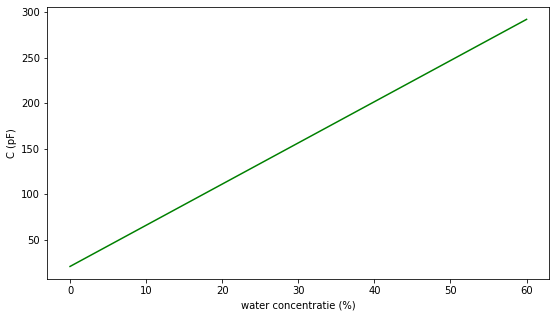

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt

A = 0.1*0.066
d = 0.005
concentratie =  np.linspace(0,0.6,1000)
epsilon_water = 78.5
epsilon_lucht = 1
epsilon_spons = 3 #schatting
epsilon_tot = 0.5*epsilon_spons + 0.5*((0.5-concentratie)*epsilon_lucht+concentratie*epsilon_water)

C = vlakkeplaat(A,d,epsilon_tot)

plt.figure(figsize=(9,5))
plt.plot(concentratie*100,C*10**12,'g')
plt.xlabel('water concentratie (%)')
plt.ylabel('C (pF)')
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 20pF | 100.5mv |
| gemiddelde capaciteit| 160pF | 794.9mv |
| maximale capaciteit| 300pF | 1449mv |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![arduino meeting](arduino_opstelling.jpg)
![close up](sensor.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

C:\Users\moene\AppData\Local\Temp\ipykernel_31620\3750861873.py:29: RuntimeWarning: divide by zero encountered in divide
  u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)
C:\Users\moene\AppData\Local\Temp\ipykernel_31620\3750861873.py:29: RuntimeWarning: invalid value encountered in multiply
  u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)


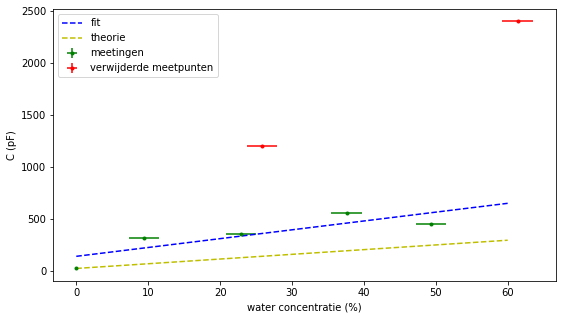

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit

#v_out_lucht_scope = 0.167
#v_out_scope = np.array([0.202, 1.21, 1.45, 2.21])
#massa_scope = np.array([0.0082, 0.0138, 0.0205, 0.0258])

u_massa = 0.0005
u_vol_tot = 2.5e-7
u_C = np.array([1,3,3,3,3,50,50])

#C_lucht_arduino = 20.0
C_arduino = np.array([24.3,310,354, 553, 453, 2400, 1200])
massa_arduino = np.array([0.0082,0.0114,0.016,0.021,0.025,0.0291,0.017])
massa_arduino_edited = massa_arduino[0:-2]
massa_arduino_verwijderd = massa_arduino[-2:]
C_arduino_edited = C_arduino[0:-2]
C_arduino_verwijderd = C_arduino[-2:]
u_C = u_C[0:-2]
u_concentratie_verwijderd = u_C[-2:]

p_water = 997 #kg/m3
vol_water = (massa_arduino_edited-massa_arduino_edited[0])/p_water
vol_water_verwijderd = (massa_arduino_verwijderd-massa_arduino_edited[0])/p_water
u_vol_water = np.sqrt(2) * u_massa / p_water
vol_tot = 0.099*0.069*0.005
concentratie_meeting = vol_water/vol_tot
concentratie_meeting_verwijderd = vol_water_verwijderd/vol_tot
u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)
u_concentratie_verwijderd = concentratie_meeting_verwijderd*np.sqrt((u_vol_water/vol_water_verwijderd)**2 + (u_vol_tot/vol_tot)**2)

def fit_func(concentratie, a, b):
    epsilon_tot = a*(1-concentratie) + epsilon_lucht*(concentratie[-1]-concentratie) + b*concentratie
    return vlakkeplaat(A,d,epsilon_tot)*10**12

var, cov = curve_fit(fit_func, concentratie_meeting, C_arduino_edited)

C_fit = fit_func(concentratie,*var)

plt.figure(figsize=(9,5))
plt.errorbar(concentratie_meeting*100,C_arduino_edited,u_C,u_concentratie*100,'g.',label='meetingen')
plt.errorbar(concentratie_meeting_verwijderd*100,C_arduino_verwijderd,u_concentratie_verwijderd,u_concentratie_verwijderd*100,'r.',label='verwijderde meetpunten')
plt.plot(concentratie*100,C_fit,'b--',label='fit')
plt.plot(concentratie*100,C*10**12,'y--', label='theorie')
plt.xlabel('water concentratie (%)')
plt.ylabel('C (pF)')
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* betere isolatie tussen te platen en de spons
* voor test meetingen een materiaal met een bekende water absorbtie en een duidenlijker volume gebruiken

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
We hebben de verbeteringen helaas niet meer uit kunnen voeren
![foto sensor](sensor.jpg)

C:\Users\moene\AppData\Local\Temp\ipykernel_31620\3750861873.py:29: RuntimeWarning: divide by zero encountered in divide
  u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)
C:\Users\moene\AppData\Local\Temp\ipykernel_31620\3750861873.py:29: RuntimeWarning: invalid value encountered in multiply
  u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)


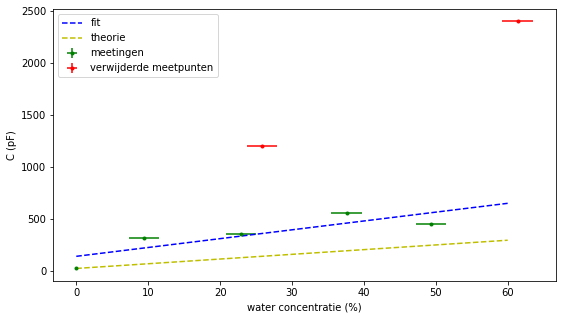

In [5]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit

#v_out_lucht_scope = 0.167
#v_out_scope = np.array([0.202, 1.21, 1.45, 2.21])
#massa_scope = np.array([0.0082, 0.0138, 0.0205, 0.0258])

u_massa = 0.0005
u_vol_tot = 2.5e-7
u_C = np.array([1,3,3,3,3,50,50])

#C_lucht_arduino = 20.0
C_arduino = np.array([24.3,310,354, 553, 453, 2400, 1200])
massa_arduino = np.array([0.0082,0.0114,0.016,0.021,0.025,0.0291,0.017])
massa_arduino_edited = massa_arduino[0:-2]
massa_arduino_verwijderd = massa_arduino[-2:]
C_arduino_edited = C_arduino[0:-2]
C_arduino_verwijderd = C_arduino[-2:]
u_C = u_C[0:-2]
u_concentratie_verwijderd = u_C[-2:]

p_water = 997 #kg/m3
vol_water = (massa_arduino_edited-massa_arduino_edited[0])/p_water
vol_water_verwijderd = (massa_arduino_verwijderd-massa_arduino_edited[0])/p_water
u_vol_water = np.sqrt(2) * u_massa / p_water
vol_tot = 0.099*0.069*0.005
concentratie_meeting = vol_water/vol_tot
concentratie_meeting_verwijderd = vol_water_verwijderd/vol_tot
u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)
u_concentratie_verwijderd = concentratie_meeting_verwijderd*np.sqrt((u_vol_water/vol_water_verwijderd)**2 + (u_vol_tot/vol_tot)**2)

def fit_func(concentratie, a, b):
    epsilon_tot = a*(1-concentratie) + epsilon_lucht*(concentratie[-1]-concentratie) + b*concentratie
    return vlakkeplaat(A,d,epsilon_tot)*10**12

var, cov = curve_fit(fit_func, concentratie_meeting, C_arduino_edited)

C_fit = fit_func(concentratie,*var)

plt.figure(figsize=(9,5))
plt.errorbar(concentratie_meeting*100,C_arduino_edited,u_C,u_concentratie*100,'g.',label='meetingen')
plt.errorbar(concentratie_meeting_verwijderd*100,C_arduino_verwijderd,u_concentratie_verwijderd,u_concentratie_verwijderd*100,'r.',label='verwijderde meetpunten')
plt.plot(concentratie*100,C_fit,'b--',label='fit')
plt.plot(concentratie*100,C*10**12,'y--', label='theorie')
plt.xlabel('water concentratie (%)')
plt.ylabel('C (pF)')
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

In dit experiment hebben we onderzocht hoe een isolatiemateriaal zich gedraagt wanneer het steeds meer water opneemt. Bij kleine hoeveelheden water veranderde de capaciteit geleiddelijk. We hebben echter ook afwijkende metingen, die niet in de curve fit zijn megenomen. Dit komt waarschijnlijk doordat het materiaal zijn verzadigingspunt bereikte en het water hierdoor ging geleiden.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](ideeen.png)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die de waterconcentratie in de spons meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](ontwerp_schets.jpg)

![Sensor Physical Model](sensor_model.png)

![Sensor Physics Model](polarisation_visual.png)

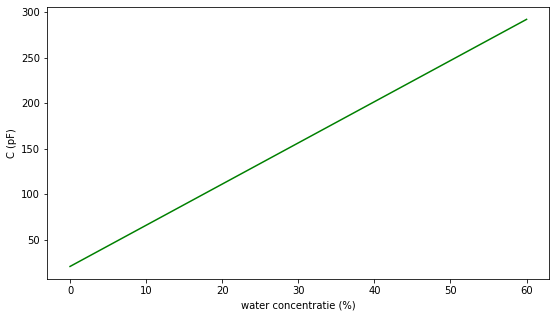

In [6]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt

A = 0.1*0.066
d = 0.005
concentratie =  np.linspace(0,0.6,1000)
epsilon_water = 78.5
epsilon_lucht = 1
epsilon_spons = 3 #schatting
epsilon_tot = 0.5*epsilon_spons + 0.5*((0.5-concentratie)*epsilon_lucht+concentratie*epsilon_water)

C_array = vlakkeplaat(A,d,epsilon_tot)

plt.figure(figsize=(9,5))
plt.plot(concentratie*100,C_array*10**12,'g')
plt.xlabel('water concentratie (%)')
plt.ylabel('C (pF)')
plt.show()

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![arduino meeting](arduino_opstelling.jpg)
![close up](sensor.jpg)

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* betere isolatie tussen te platen en de spons
* voor test meetingen een materiaal met een bekende water absorbtie en een duidenlijker volume gebruiken

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
We hebben de verbeteringen helaas niet meer uit kunnen voeren
![foto sensor](sensor.jpg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="test_cap_schets.jpg" alt="test cap schets" width="400"/>

In [7]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

epsilon_0 = 8.854e-12

def vlakkeplaat(A, d, epsilon_r):
    C = epsilon_0 * epsilon_r * A / d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [8]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
A = 0.1*0.1 #m^2
d = 0.0001 #m
epsilon_papier = 3.78

C = vlakkeplaat(A,d,epsilon_papier)


print(f"Berekende capaciteit plaatcondensator groep 34 is {C*10**12:.0f} pF")



Berekende capaciteit plaatcondensator groep 34 is 3347 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![test cap](test_cap.jpg)
![scope meting](test_cap_meeting.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 34| 3347pF | 33.6v | 9.45v | 940pF |

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 20pF | 100.5mv |
| gemiddelde capaciteit| 135pF | 675.3mv |
| maximale capaciteit| 250pF | 1222mv |

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

## Opdracht 7: Plot de kalibratiegrafiek.

C:\Users\moene\AppData\Local\Temp\ipykernel_31620\3684097919.py:29: RuntimeWarning: divide by zero encountered in divide
  u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)
C:\Users\moene\AppData\Local\Temp\ipykernel_31620\3684097919.py:29: RuntimeWarning: invalid value encountered in multiply
  u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)


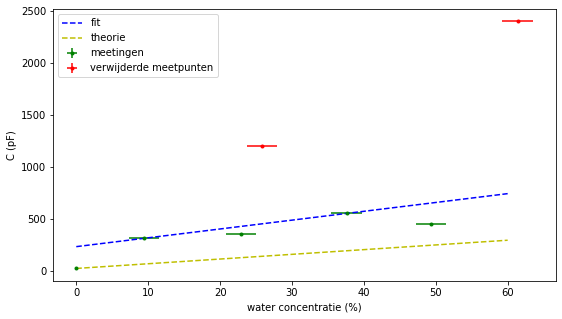

In [9]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit

#v_out_lucht_scope = 0.167
#v_out_scope = np.array([0.202, 1.21, 1.45, 2.21])
#massa_scope = np.array([0.0082, 0.0138, 0.0205, 0.0258])

u_massa = 0.0005
u_vol_tot = 2.5e-7
u_C = np.array([1,3,3,3,3,50,50])

#C_lucht_arduino = 20.0
C_arduino = np.array([24.3,310,354, 553, 453, 2400, 1200])
massa_arduino = np.array([0.0082,0.0114,0.016,0.021,0.025,0.0291,0.017])
massa_arduino_edited = massa_arduino[0:-2]
massa_arduino_verwijderd = massa_arduino[-2:]
C_arduino_edited = C_arduino[0:-2]
C_arduino_verwijderd = C_arduino[-2:]
u_C = u_C[0:-2]
u_concentratie_verwijderd = u_C[-2:]

p_water = 997 #kg/m3
vol_water = (massa_arduino_edited-massa_arduino_edited[0])/p_water
vol_water_verwijderd = (massa_arduino_verwijderd-massa_arduino_edited[0])/p_water
u_vol_water = np.sqrt(2) * u_massa / p_water
vol_tot = 0.099*0.069*0.005
concentratie_meeting = vol_water/vol_tot
concentratie_meeting_verwijderd = vol_water_verwijderd/vol_tot
u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)
u_concentratie_verwijderd = concentratie_meeting_verwijderd*np.sqrt((u_vol_water/vol_water_verwijderd)**2 + (u_vol_tot/vol_tot)**2)

def fit_func(concentratie, a,b):
    epsilon_tot = a*(1-concentratie) + epsilon_lucht*(concentratie[-1]-concentratie) + b*concentratie
    return vlakkeplaat(A,d,epsilon_tot)*10**12

var, cov = curve_fit(fit_func, concentratie_meeting, C_arduino_edited)

C_fit = fit_func(concentratie,*var)

plt.figure(figsize=(9,5))
plt.errorbar(concentratie_meeting*100,C_arduino_edited,u_C,u_concentratie*100,'g.',label='meetingen')
plt.errorbar(concentratie_meeting_verwijderd*100,C_arduino_verwijderd,u_concentratie_verwijderd,u_concentratie_verwijderd*100,'r.',label='verwijderde meetpunten')
plt.plot(concentratie*100,C_fit,'b--',label='fit')
plt.plot(concentratie*100,C_array*10**12,'y--', label='theorie')
plt.xlabel('water concentratie (%)')
plt.ylabel('C (pF)')
plt.legend()
plt.show()

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

C:\Users\moene\AppData\Local\Temp\ipykernel_31620\2695110830.py:29: RuntimeWarning: divide by zero encountered in divide
  u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)
C:\Users\moene\AppData\Local\Temp\ipykernel_31620\2695110830.py:29: RuntimeWarning: invalid value encountered in multiply
  u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)


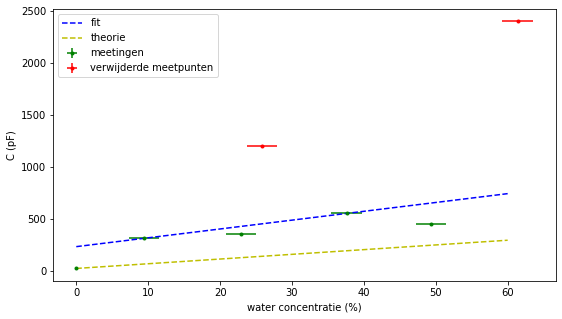

In [10]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit

#v_out_lucht_scope = 0.167
#v_out_scope = np.array([0.202, 1.21, 1.45, 2.21])
#massa_scope = np.array([0.0082, 0.0138, 0.0205, 0.0258])

u_massa = 0.0005
u_vol_tot = 2.5e-7
u_C = np.array([1,3,3,3,3,50,50])

#C_lucht_arduino = 20.0
C_arduino = np.array([24.3,310,354, 553, 453, 2400, 1200])
massa_arduino = np.array([0.0082,0.0114,0.016,0.021,0.025,0.0291,0.017])
massa_arduino_edited = massa_arduino[0:-2]
massa_arduino_verwijderd = massa_arduino[-2:]
C_arduino_edited = C_arduino[0:-2]
C_arduino_verwijderd = C_arduino[-2:]
u_C = u_C[0:-2]
u_concentratie_verwijderd = u_C[-2:]

p_water = 997 #kg/m3
vol_water = (massa_arduino_edited-massa_arduino_edited[0])/p_water
vol_water_verwijderd = (massa_arduino_verwijderd-massa_arduino_edited[0])/p_water
u_vol_water = np.sqrt(2) * u_massa / p_water
vol_tot = 0.099*0.069*0.005
concentratie_meeting = vol_water/vol_tot
concentratie_meeting_verwijderd = vol_water_verwijderd/vol_tot
u_concentratie = concentratie_meeting*np.sqrt((u_vol_water/vol_water)**2 + (u_vol_tot/vol_tot)**2)
u_concentratie_verwijderd = concentratie_meeting_verwijderd*np.sqrt((u_vol_water/vol_water_verwijderd)**2 + (u_vol_tot/vol_tot)**2)

def fit_func(concentratie, a, b):
    epsilon_tot = a*(1-concentratie) + epsilon_lucht*(concentratie[-1]-concentratie) + b*concentratie
    return vlakkeplaat(A,d,epsilon_tot)*10**12

var, cov = curve_fit(fit_func, concentratie_meeting, C_arduino_edited)

C_fit = fit_func(concentratie,*var)

plt.figure(figsize=(9,5))
plt.errorbar(concentratie_meeting*100,C_arduino_edited,u_C,u_concentratie*100,'g.',label='meetingen')
plt.errorbar(concentratie_meeting_verwijderd*100,C_arduino_verwijderd,u_concentratie_verwijderd,u_concentratie_verwijderd*100,'r.',label='verwijderde meetpunten')
plt.plot(concentratie*100,C_fit,'b--',label='fit')
plt.plot(concentratie*100,C_array*10**12,'y--', label='theorie')
plt.xlabel('water concentratie (%)')
plt.ylabel('C (pF)')
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

In dit experiment hebben we onderzocht hoe een isolatiemateriaal zich gedraagt wanneer het steeds meer water opneemt. Bij kleine hoeveelheden water veranderde de capaciteit geleiddelijk. We hebben echter ook afwijkende metingen, die niet in de curve fit zijn megenomen. Dit komt waarschijnlijk doordat het materiaal zijn verzadigingspunt bereikte en het water hierdoor ging geleiden.